In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Twitter_Data.csv")

In [3]:
df.head(5)

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  str    
 1   category    162973 non-null  float64
dtypes: float64(1), str(1)
memory usage: 21.9 MB


In [5]:
df.shape

(162980, 2)

##  Data Cleaning

In [6]:
df.isna().sum()

clean_text    4
category      7
dtype: int64

In [7]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(df.shape)

(162969, 2)


In [8]:
df.isna().sum()

clean_text    0
category      0
dtype: int64

In [9]:
#! pip install nltk emoji

# Text Preprocessing (NLP)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

import nltk
from nltk.corpus import stopwords
import re

In [11]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
import emoji

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to C:\Users\ANKIT
[nltk_data]     AGRAWAL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ANKIT
[nltk_data]     AGRAWAL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\ANKIT
[nltk_data]     AGRAWAL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [12]:
def advanced_preprocess(text):

    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)

    text = emoji.replace_emoji(text, replace='')

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = word_tokenize(text)

    tokens = [w for w in tokens if w not in stop_words] # type: ignore

    tokens = [lemmatizer.lemmatize(w) for w in tokens] # type: ignore

    return " ".join(tokens)

In [13]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    
    text = text.lower()
    
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"@\w+", "", text)     # remove mentions
    text = re.sub(r"[^a-zA-Z ]", "", text)
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

df['processed_text'] = df['clean_text'].apply(preprocess)

[nltk_data] Downloading package stopwords to C:\Users\ANKIT
[nltk_data]     AGRAWAL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
df[['clean_text','processed_text']].head()

,clean_text,processed_text
0,when modi promised “minimum government maximum...,modi promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,asking supporters prefix chowkidar names modi ...
4,answer who among these the most powerful world...,answer among powerful world leader today trump...


## Outlier Detection

In [15]:
df['text_length'] = df['processed_text'].apply(len)

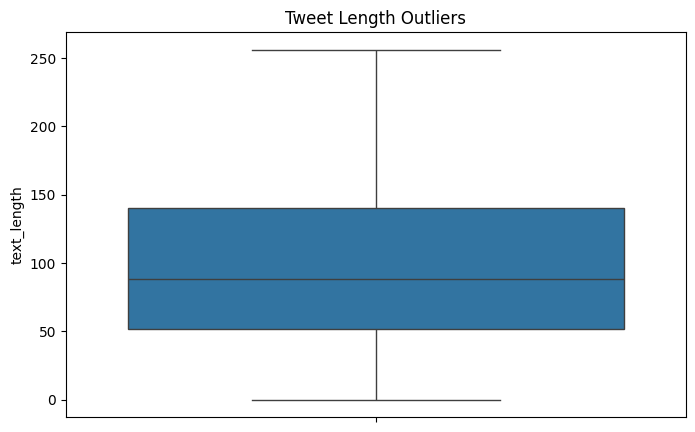

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(df['text_length'])
plt.title("Tweet Length Outliers")
plt.show()

# Feature Engineering (TF-IDF)

 ## Convert text → numeric features.

In [18]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['processed_text'])

y = df['category']

# . Train Test Split

In [19]:
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Algorithm 1 — Naive Bayes

In [20]:
nb = MultinomialNB()

nb.fit(X_train_ml, y_train_ml)

y_pred_nb = nb.predict(X_test_ml)

print("Naive Bayes Accuracy:", accuracy_score(y_test_ml, y_pred_nb))
print(classification_report(y_test_ml, y_pred_nb))

Naive Bayes Accuracy: 0.7229858256120758
              precision    recall  f1-score   support

        -1.0       0.87      0.43      0.58      7152
         0.0       0.83      0.65      0.73     11067
         1.0       0.65      0.92      0.76     14375

    accuracy                           0.72     32594
   macro avg       0.79      0.67      0.69     32594
weighted avg       0.76      0.72      0.71     32594



# Algorithm 2 — Support Vector Machine (SVM)

In [21]:
svm = LinearSVC()

svm.fit(X_train_ml, y_train_ml)

y_pred_svm = svm.predict(X_test_ml)

print("SVM Accuracy:", accuracy_score(y_test_ml, y_pred_svm))
print(classification_report(y_test_ml, y_pred_svm))

SVM Accuracy: 0.8979259986500583
              precision    recall  f1-score   support

        -1.0       0.88      0.81      0.84      7152
         0.0       0.87      0.97      0.92     11067
         1.0       0.93      0.89      0.91     14375

    accuracy                           0.90     32594
   macro avg       0.89      0.89      0.89     32594
weighted avg       0.90      0.90      0.90     32594



# Algorithm 3 — Random Forest

In [22]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train_ml, y_train_ml)

y_pred_rf = rf.predict(X_test_ml)

print("Random Forest Accuracy:", accuracy_score(y_test_ml, y_pred_rf))
print(classification_report(y_test_ml, y_pred_rf))

Random Forest Accuracy: 0.8601276308523041
              precision    recall  f1-score   support

        -1.0       0.87      0.69      0.77      7152
         0.0       0.83      0.96      0.89     11067
         1.0       0.88      0.87      0.87     14375

    accuracy                           0.86     32594
   macro avg       0.86      0.84      0.85     32594
weighted avg       0.86      0.86      0.86     32594



# Deep Learning Model (LSTM)

In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [24]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['processed_text'])

X_seq = tokenizer.texts_to_sequences(df['processed_text'])

X_pad = pad_sequences(X_seq, maxlen=100)

y = df['category']

In [25]:
df['category'] = df['category'].replace({
    -1:0,
     0:1,
     1:2
})

In [26]:
print(df['category'].unique())

[0. 1. 2.]


In [27]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, df['category'], test_size=0.2, random_state=42
)

In [28]:
model = Sequential()

model.add(Embedding(10000, 128, input_length=100))
model.add(LSTM(64))
model.add(Dense(3, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=64)

c:\Users\ANKIT AGRAWAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 114s 55ms/step - accuracy: 0.8665 - loss: 0.3885
Epoch 2/5
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 118s 58ms/step - accuracy: 0.9198 - loss: 0.2669
Epoch 3/5
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 110s 54ms/step - accuracy: 0.9272 - loss: 0.2323
Epoch 4/5
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 125s 61ms/step - accuracy: 0.9378 - loss: 0.1906
Epoch 5/5
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 123s 60ms/step - accuracy: 0.9511 - loss: 0.1483


In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,811 (15.22 MB)

 Trainable params: 1,329,603 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,659,208 (10.14 MB)

In [30]:
nb_acc = accuracy_score(y_test_ml, y_pred_nb)
svm_acc = accuracy_score(y_test_ml, y_pred_svm)
rf_acc = accuracy_score(y_test_ml, y_pred_rf)

In [31]:
import pandas as pd

accuracy_summary = pd.DataFrame({
    'Model': ['Naive Bayes','SVM','Random Forest'],
    'Accuracy': [nb_acc, svm_acc, rf_acc]
})

accuracy_summary

,Model,Accuracy
0,Naive Bayes,0.722986
1,SVM,0.897926
2,Random Forest,0.860128


# Sentiment Distribution Visualization

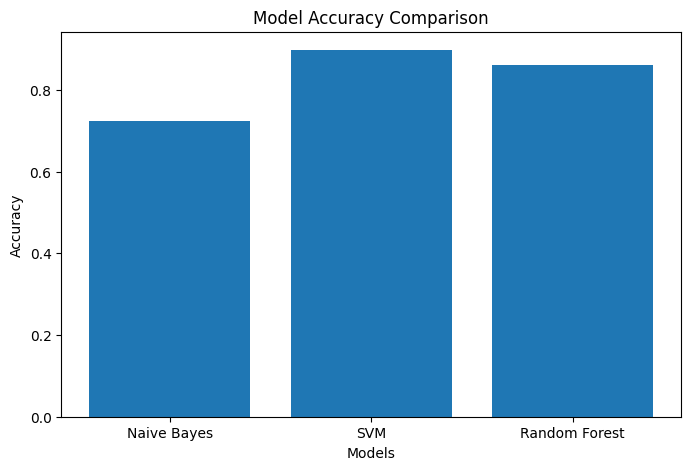

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(accuracy_summary['Model'], accuracy_summary['Accuracy'])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

In [33]:
df.to_csv("twitter_sentiment_cleaned.csv", index=False)

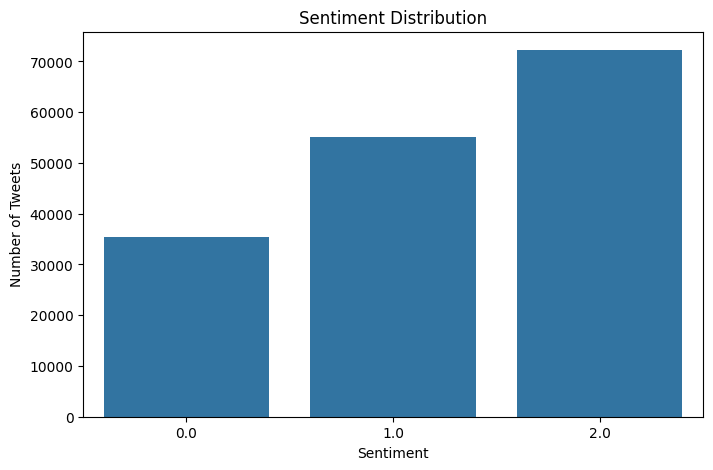

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(x='category', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

## Pie Chart of Sentiments

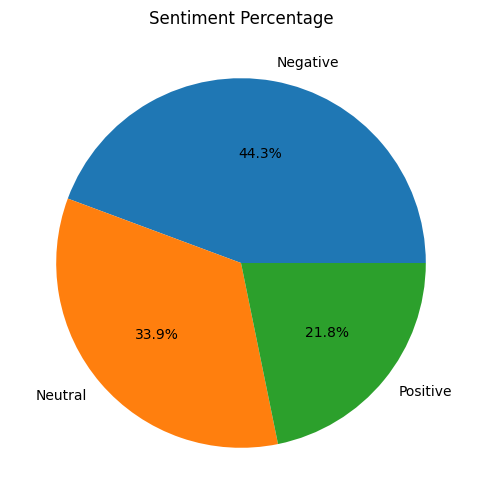

In [36]:
sentiment_counts = df['category'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=['Negative','Neutral','Positive'],
    autopct='%1.1f%%'
)

plt.title("Sentiment Percentage")

plt.show()

## Tweet Length Distribution

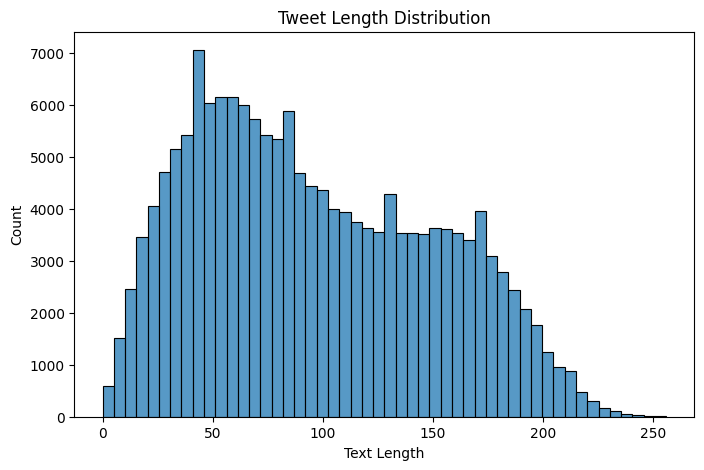

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df['text_length'], bins=50)

plt.title("Tweet Length Distribution")
plt.xlabel("Text Length")

plt.show()

# WordCloud for Positive Tweets

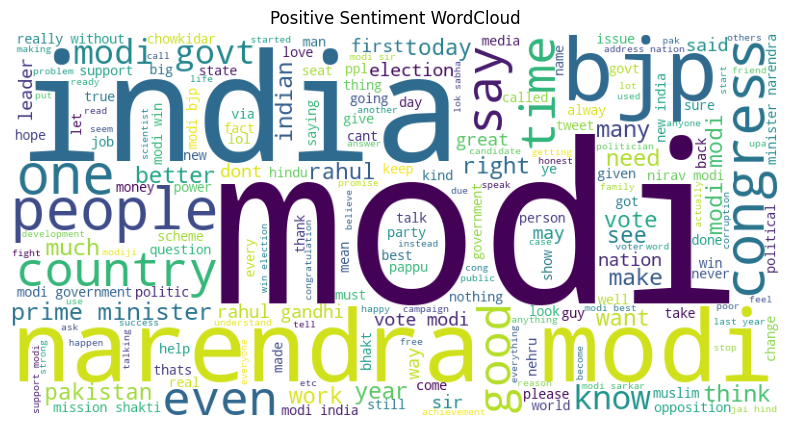

In [38]:
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['category']==2]['processed_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Sentiment WordCloud")
plt.show()

## Confusion Matrix (Important for ML Projects)

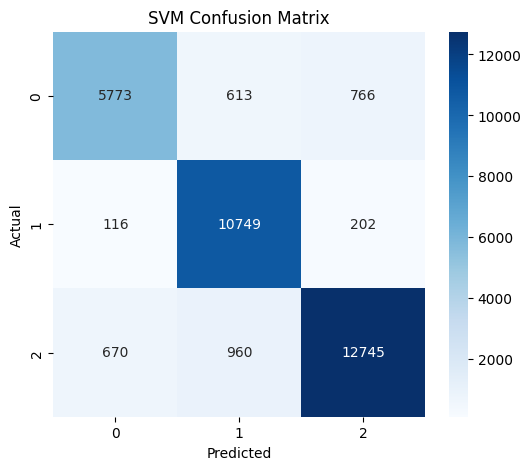

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_ml, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Most Frequent Words

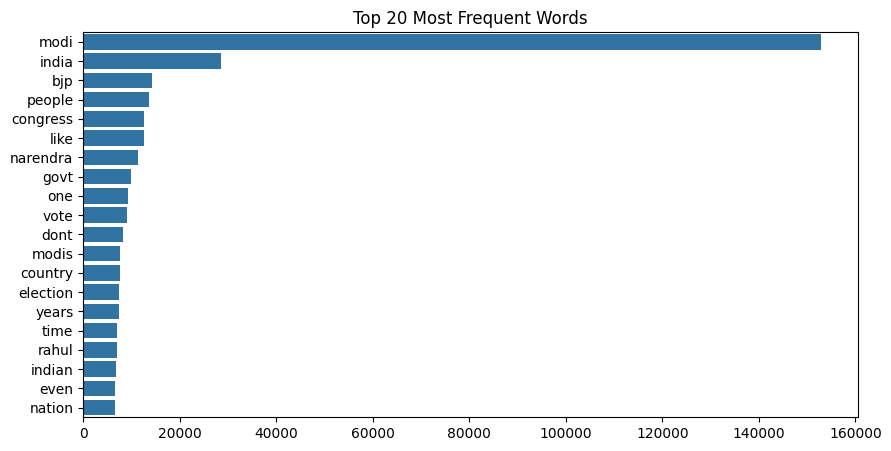

In [40]:
from collections import Counter

all_words = " ".join(df['processed_text']).split()

common_words = Counter(all_words).most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Frequent Words")

plt.show()

## t-SNE Sentiment Clustering Visualization

This is a very powerful visualization used in NLP research.

It reduces high-dimensional text features → 2D visualization.

If the model works well, sentiments will form clusters.

In [48]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

X_sample = X[:3000].toarray()

X_tsne = tsne.fit_transform(X_sample)

In [50]:
tsne_df = pd.DataFrame()

tsne_df["x"] = X_tsne[:,0]
tsne_df["y"] = X_tsne[:,1]

tsne_df["sentiment"] = y[:3000].values

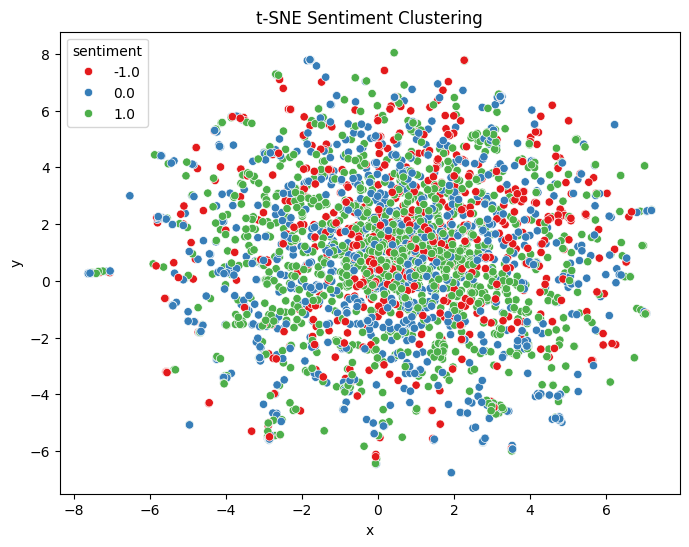

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="x",
    y="y",
    hue="sentiment",
    palette="Set1",
    data=tsne_df
)

plt.title("t-SNE Sentiment Clustering")

plt.show()

## Bonus Visualization (Very Useful)
Sentiment Probability Distribution

Shows model confidence.

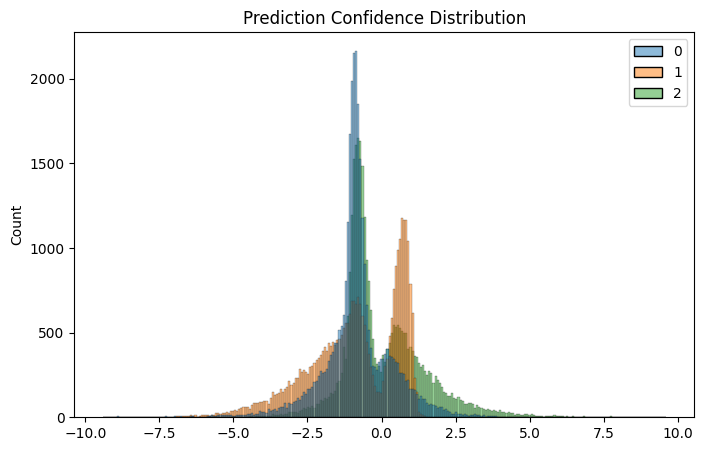

In [52]:
probs = svm.decision_function(X_test_ml)

plt.figure(figsize=(8,5))

sns.histplot(probs)

plt.title("Prediction Confidence Distribution")

plt.show()